# v1 Steals Modeling — All Lines (0.5 + 1.5)

This notebook models **both 0.5 and 1.5 steals lines** using separate model tiers across 3 seasons (2023-24, 2024-25, 2025-26) with walk-forward validation.

**Market context:**
- 0.5 line: over ~-182, under ~+117 → de-vigged P(over) ≈ 58%. Market is confident most players get ≥1 steal. The under is the value target — it requires the model to identify near-zero-steal games.
- 1.5 line: over ~+99, under ~-169 → de-vigged P(over) ≈ 44%. Closer to 50/50, more symmetric modeling opportunity.

**Goals:** (a) characterize both markets, (b) test whether a model can find edge at the 0.5 under (beating +117), (c) compare 0.5 vs 1.5 model performance side-by-side.

## Section 1: Setup & Data Load

In [1]:
import sys
from pathlib import Path
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss
from sklearn.preprocessing import StandardScaler

repo_root = Path(subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip())
sys.path.insert(0, str(repo_root))
from src.nba_rebounds_modeling.duckdb_s3_creds import connect_duckdb_s3

con = connect_duckdb_s3()
print(f"repo_root={repo_root}")

SEASONS = ["2023-24", "2024-25", "2025-26"]

SEASON_DATE_RANGES = {
    "2023-24": ("2023-10-01", "2024-06-30"),
    "2024-25": ("2024-10-01", "2025-06-30"),
    "2025-26": ("2025-10-01", "2026-06-30"),
}

FEAT_COLS = [
    "stl_roll5", "stl_roll10", "stl_roll20", "stl_roll40",
    "stl_per_min_roll10", "stl_per_min_roll20",
    "min_roll5", "min_roll10",
]

def american_to_implied_prob(odds: float) -> float:
    if pd.isna(odds):
        return float("nan")
    if odds < 0:
        return (-odds) / ((-odds) + 100.0)
    return 100.0 / (odds + 100.0)

def american_profit(odds: float) -> float:
    if odds >= 0:
        return odds / 100.0
    return 100.0 / (-odds)

repo_root=/Users/thomasmyles/dev/betting


In [2]:
# --- Load game logs (all 3 seasons) ---
log_frames = []
for season in SEASONS:
    q = f"""
        SELECT
            PLAYER_NAME, GAME_DATE, STL, MIN, MATCHUP, WL,
            TEAM_NAME, AST, REB, PTS, FGA, FG3A, FTA, TOV, BLK
        FROM read_csv_auto('s3://nba-api-mt/player_game_logs/{season}/*.csv',
                           header=true, ignore_errors=true)
    """
    df_s = con.execute(q).df()
    df_s["season"] = season
    log_frames.append(df_s)
    print(f"  {season}: {len(df_s):,} rows")

df_logs = pd.concat(log_frames, ignore_index=True)

# Drop zero-minute rows
df_logs = df_logs[df_logs["MIN"] > 0].copy()

# Parse GAME_DATE
df_logs["game_date"] = pd.to_datetime(df_logs["GAME_DATE"], format="mixed").dt.normalize()

# Normalize player name for join
df_logs["player_normalized"] = df_logs["PLAYER_NAME"].str.lower().str.strip()

print(f"\nTotal game logs: {len(df_logs):,} rows | {df_logs['PLAYER_NAME'].nunique():,} players")
print(f"Date range: {df_logs['game_date'].min().date()} → {df_logs['game_date'].max().date()}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2023-24: 26,401 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2024-25: 26,306 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2025-26: 28,427 rows

Total game logs: 81,034 rows | 803 players
Date range: 2023-10-24 → 2026-05-17


In [3]:
# --- Load steals props (0.5 and 1.5 lines only) ---
prop_frames = []
for season in SEASONS:
    start_dt, end_dt = SEASON_DATE_RANGES[season]
    q = f"""
        SELECT
            player, away_team, home_team, game_time,
            market, prop_line, bookmaker,
            over_odds, under_odds, fetch_date, season
        FROM read_csv_auto('s3://the-odds-api-mt/nba/historical_player_props/{season}/*.csv',
                           header=true, ignore_errors=true)
        WHERE market = 'player_steals'
          AND prop_line IN (0.5, 1.5)
          AND CAST(game_time AS TIMESTAMP) >= TIMESTAMP '{start_dt}'
          AND CAST(game_time AS TIMESTAMP) <= TIMESTAMP '{end_dt} 23:59:59'
    """
    df_p = con.execute(q).df()
    prop_frames.append(df_p)
    print(f"  {season}: {len(df_p):,} rows")

df_props_raw = pd.concat(prop_frames, ignore_index=True)

# Parse game_time → game_date
df_props_raw["game_date"] = pd.to_datetime(df_props_raw["game_time"], utc=True).dt.tz_localize(None).dt.normalize()

# Normalize player name for join
df_props_raw["player_normalized"] = df_props_raw["player"].str.lower().str.strip()

# Aggregate to one row per (player, game_date, prop_line) — median odds across bookmakers
df_props = (
    df_props_raw
    .groupby(["player_normalized", "game_date", "prop_line"], as_index=False)
    .agg(
        over_odds=("over_odds", "median"),
        under_odds=("under_odds", "median"),
        player=("player", "first"),
    )
)

print(f"\nAggregated props: {len(df_props):,} rows")
print(f"  0.5 line: {(df_props['prop_line']==0.5).sum():,} | 1.5 line: {(df_props['prop_line']==1.5).sum():,}")
print(f"Date range: {df_props['game_date'].min().date()} → {df_props['game_date'].max().date()}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2023-24: 47,474 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2024-25: 22,551 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  2025-26: 9,711 rows

Aggregated props: 25,944 rows
  0.5 line: 15,471 | 1.5 line: 10,473
Date range: 2023-10-24 → 2026-05-23


In [4]:
# --- Join props to game logs, split by line tier ---
joined = df_props.merge(
    df_logs,
    on=["player_normalized", "game_date"],
    how="inner",
)

n_props = len(df_props)
n_joined = len(joined)
print(f"Props rows:  {n_props:,}")
print(f"Joined rows: {n_joined:,}  ({n_joined/n_props*100:.1f}% match rate)")

df = joined.copy()
df_05 = df[df["prop_line"] == 0.5].copy()   # P(STL >= 1)
df_15 = df[df["prop_line"] == 1.5].copy()   # P(STL >= 2)

# Drop low-minute rows (< 15 min) — near-zero steal opportunity
df_05 = df_05[df_05["MIN"] >= 15].copy()
df_15 = df_15[df_15["MIN"] >= 15].copy()

print(f"\n0.5 line: {len(df_05):,} rows | 1.5 line: {len(df_15):,} rows")

Props rows:  25,944
Joined rows: 7,609  (29.3% match rate)

0.5 line: 4,333 rows | 1.5 line: 3,093 rows


## EDA

In [5]:
# --- Side-by-side market summary ---
for label, sub, thresh in [
    ("0.5 line (P(STL>=1))", df_05, 1),
    ("1.5 line (P(STL>=2))", df_15, 2),
]:
    sub = sub.copy()
    sub["y"] = (sub["STL"] >= thresh).astype(int)
    sub["p_over_raw"] = sub["over_odds"].apply(american_to_implied_prob)
    sub["p_under_raw"] = sub["under_odds"].apply(american_to_implied_prob)
    sub["p_mkt"] = sub["p_over_raw"] / (sub["p_over_raw"] + sub["p_under_raw"])
    print(f"\n=== {label} ===")
    print(f"  n={len(sub):,}, players={sub['PLAYER_NAME'].nunique()}")
    print(f"  date range: {sub['game_date'].min().date()} → {sub['game_date'].max().date()}")
    print(f"  actual over rate:    {sub['y'].mean():.3f}")
    print(f"  de-vigged P(over):   {sub['p_mkt'].mean():.3f}")
    print(f"  calibration gap:     {abs(sub['p_mkt'].mean() - sub['y'].mean()):.3f}")
    print(f"  median over_odds:    {sub['over_odds'].median():.0f}")
    print(f"  median under_odds:   {sub['under_odds'].median():.0f}")


=== 0.5 line (P(STL>=1)) ===
  n=4,333, players=327
  date range: 2023-10-24 → 2026-05-15
  actual over rate:    0.574
  de-vigged P(over):   0.573
  calibration gap:     0.001
  median over_odds:    -166
  median under_odds:   125

=== 1.5 line (P(STL>=2)) ===
  n=3,093, players=254
  date range: 2023-10-24 → 2026-05-15
  actual over rate:    0.360
  de-vigged P(over):   0.403
  calibration gap:     0.042
  median over_odds:    145
  median under_odds:   -190


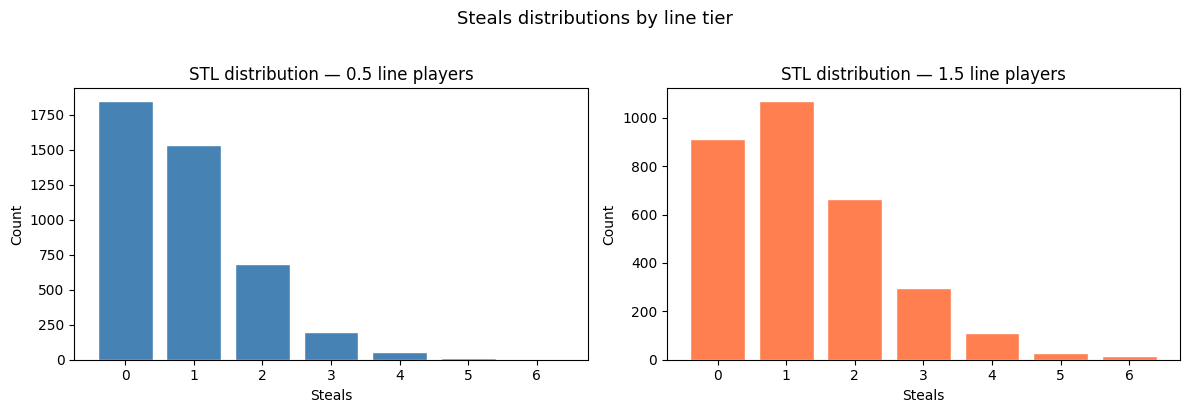

0.5 line — mean STL: 0.875 | 0-steal rate: 0.426
1.5 line — mean STL: 1.280 | 0-steal rate: 0.294


In [6]:
# --- STL distribution: players on 0.5 lines vs 1.5 lines ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

axes[0].hist(df_05["STL"].clip(upper=6), bins=range(8), align="left", rwidth=0.8, color="steelblue", edgecolor="white")
axes[0].set_title("STL distribution — 0.5 line players", fontsize=12)
axes[0].set_xlabel("Steals")
axes[0].set_ylabel("Count")
axes[0].set_xticks(range(7))

axes[1].hist(df_15["STL"].clip(upper=6), bins=range(8), align="left", rwidth=0.8, color="coral", edgecolor="white")
axes[1].set_title("STL distribution — 1.5 line players", fontsize=12)
axes[1].set_xlabel("Steals")
axes[1].set_ylabel("Count")
axes[1].set_xticks(range(7))

plt.suptitle("Steals distributions by line tier", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"0.5 line — mean STL: {df_05['STL'].mean():.3f} | 0-steal rate: {(df_05['STL']==0).mean():.3f}")
print(f"1.5 line — mean STL: {df_15['STL'].mean():.3f} | 0-steal rate: {(df_15['STL']==0).mean():.3f}")

### EDA VERDICT:
```
# TODO: fill in after running
```

## Feature Engineering

In [7]:
# Build rolling features on the union of both populations, then re-join back.
# Using deduplicated player-game rows to avoid computing features twice.
df_all = pd.concat([df_05, df_15]).drop_duplicates(subset=["PLAYER_NAME", "game_date"]).copy()
df_all = df_all.sort_values(["PLAYER_NAME", "game_date"]).reset_index(drop=True)

# Rolling steal and minute windows
for w in [5, 10, 20, 40]:
    df_all[f"stl_roll{w}"] = (
        df_all.groupby("PLAYER_NAME")["STL"]
        .transform(lambda x: x.shift(1).rolling(w, min_periods=max(1, w // 2)).mean())
    )
    df_all[f"min_roll{w}"] = (
        df_all.groupby("PLAYER_NAME")["MIN"]
        .transform(lambda x: x.shift(1).rolling(w, min_periods=max(1, w // 2)).mean())
    )

# Steals per minute (rate feature)
df_all["stl_per_min"] = df_all["STL"] / df_all["MIN"].clip(lower=1)
for w in [10, 20]:
    df_all[f"stl_per_min_roll{w}"] = (
        df_all.groupby("PLAYER_NAME")["stl_per_min"]
        .transform(lambda x: x.shift(1).rolling(w, min_periods=max(1, w // 2)).mean())
    )

feat_join_cols = ["PLAYER_NAME", "game_date"] + FEAT_COLS

# Re-join features back into each line-tier frame
df_05 = df_05.merge(df_all[feat_join_cols], on=["PLAYER_NAME", "game_date"], how="left")
df_15 = df_15.merge(df_all[feat_join_cols], on=["PLAYER_NAME", "game_date"], how="left")

# Target variables
df_05["y"] = (df_05["STL"] >= 1).astype(int)
df_15["y"] = (df_15["STL"] >= 2).astype(int)

# De-vigged market probability
for df_tier in [df_05, df_15]:
    df_tier["p_over_raw"] = df_tier["over_odds"].apply(american_to_implied_prob)
    df_tier["p_under_raw"] = df_tier["under_odds"].apply(american_to_implied_prob)
    df_tier["p_mkt"] = df_tier["p_over_raw"] / (df_tier["p_over_raw"] + df_tier["p_under_raw"])

print(f"Features computed.")
print(f"0.5 line — {df_05[FEAT_COLS].notna().all(axis=1).sum():,} / {len(df_05):,} rows have complete features")
print(f"1.5 line — {df_15[FEAT_COLS].notna().all(axis=1).sum():,} / {len(df_15):,} rows have complete features")

Features computed.
0.5 line — 1,404 / 4,333 rows have complete features
1.5 line — 1,577 / 3,093 rows have complete features


## Univariate Feature Ranking

In [8]:
# Compute correlation with y for each feature, separately per line tier
rows_05 = []
rows_15 = []

for feat in FEAT_COLS:
    corr_05 = df_05[[feat, "y"]].dropna()[feat].corr(df_05[[feat, "y"]].dropna()["y"])
    corr_15 = df_15[[feat, "y"]].dropna()[feat].corr(df_15[[feat, "y"]].dropna()["y"])
    rows_05.append({"feature": feat, "corr_with_y": round(corr_05, 4)})
    rows_15.append({"feature": feat, "corr_with_y": round(corr_15, 4)})

rank_05 = pd.DataFrame(rows_05).sort_values("corr_with_y", key=abs, ascending=False)
rank_15 = pd.DataFrame(rows_15).sort_values("corr_with_y", key=abs, ascending=False)

print("=== 0.5 line (P(STL>=1)) ===")
print(rank_05.to_string(index=False))
print()
print("=== 1.5 line (P(STL>=2)) ===")
print(rank_15.to_string(index=False))

=== 0.5 line (P(STL>=1)) ===
           feature  corr_with_y
        stl_roll40       0.1179
        stl_roll20       0.0916
stl_per_min_roll20       0.0897
        stl_roll10       0.0811
stl_per_min_roll10       0.0769
         stl_roll5       0.0535
         min_roll5       0.0363
        min_roll10       0.0302

=== 1.5 line (P(STL>=2)) ===
           feature  corr_with_y
        stl_roll10       0.1035
        stl_roll20       0.0979
stl_per_min_roll10       0.0979
stl_per_min_roll20       0.0978
        stl_roll40       0.0871
         stl_roll5       0.0791
         min_roll5       0.0078
        min_roll10       0.0015


### Feature Verdict:
```
# TODO: fill in after running
```

## Single-Season Baseline — 2025-26

In [9]:
FEAT_A = ["stl_roll10", "min_roll10"]
FEAT_B = ["stl_roll10", "stl_roll20", "stl_per_min_roll10", "min_roll10"]

def fit_eval_logreg(df_tier, feat_cols, cutoff_date="2025-03-01"):
    """
    80/20-ish train/test split by date. Returns (brier_model, brier_market, n_test).
    """
    sub = df_tier.dropna(subset=feat_cols + ["y", "p_mkt"]).copy()
    sub = sub.sort_values("game_date")
    train = sub[sub["game_date"] < cutoff_date]
    test = sub[sub["game_date"] >= cutoff_date]
    if len(train) < 20 or len(test) < 10:
        return None, None, 0
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(train[feat_cols])
    X_te = scaler.transform(test[feat_cols])
    clf = LogisticRegression(max_iter=1000, C=1.0)
    clf.fit(X_tr, train["y"])
    p_model = clf.predict_proba(X_te)[:, 1]
    brier_model = brier_score_loss(test["y"], p_model)
    brier_mkt = brier_score_loss(test["y"], test["p_mkt"])
    return brier_model, brier_mkt, len(test)

# Filter to 2025-26 only
df_05_2526 = df_05[df_05["season"] == "2025-26"].copy()
df_15_2526 = df_15[df_15["season"] == "2025-26"].copy()

results = []
for line_label, df_tier in [("0.5", df_05_2526), ("1.5", df_15_2526)]:
    for model_label, feat_cols in [("FEAT_A", FEAT_A), ("FEAT_B", FEAT_B)]:
        brier_m, brier_mkt, n_test = fit_eval_logreg(df_tier, feat_cols)
        if brier_m is None:
            results.append({"line": line_label, "model": model_label, "brier": None,
                            "n_test": 0, "brier_vs_market": None})
        else:
            results.append({
                "line": line_label,
                "model": model_label,
                "brier": round(brier_m, 4),
                "n_test": n_test,
                "brier_market": round(brier_mkt, 4),
                "brier_vs_market": round(brier_m - brier_mkt, 4),
            })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

line  model brier  n_test brier_vs_market
 0.5 FEAT_A  None       0            None
 0.5 FEAT_B  None       0            None
 1.5 FEAT_A  None       0            None
 1.5 FEAT_B  None       0            None


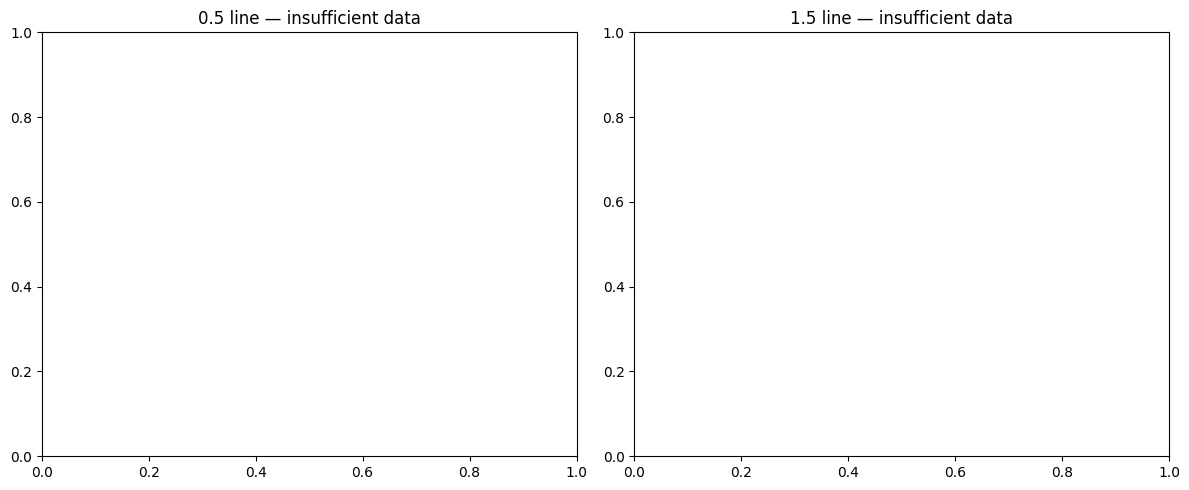

In [10]:
# --- Calibration plots: model vs de-vigged market (2025-26 OOS) ---
def get_oos_preds(df_tier, feat_cols, cutoff_date="2025-03-01"):
    sub = df_tier.dropna(subset=feat_cols + ["y", "p_mkt"]).copy()
    sub = sub.sort_values("game_date")
    train = sub[sub["game_date"] < cutoff_date]
    test = sub[sub["game_date"] >= cutoff_date]
    if len(train) < 20 or len(test) < 10:
        return None
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(train[feat_cols])
    X_te = scaler.transform(test[feat_cols])
    clf = LogisticRegression(max_iter=1000, C=1.0)
    clf.fit(X_tr, train["y"])
    test = test.copy()
    test["p_model"] = clf.predict_proba(X_te)[:, 1]
    return test

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (line_label, df_tier) in zip(axes, [("0.5 line", df_05_2526), ("1.5 line", df_15_2526)]):
    test_df = get_oos_preds(df_tier, FEAT_B)
    if test_df is None:
        ax.set_title(f"{line_label} — insufficient data")
        continue
    ax.scatter(test_df["p_mkt"], test_df["p_model"], alpha=0.2, s=8, color="steelblue")
    ax.plot([0.30, 0.70], [0.30, 0.70], "r--", linewidth=1, label="perfect calibration")
    ax.set_xlim(0.30, 0.70)
    ax.set_ylim(0.30, 0.70)
    ax.set_xlabel("De-vigged market P(over)")
    ax.set_ylabel("Model P(over)")
    ax.set_title(f"Calibration — {line_label} (FEAT_B, 2025-26 OOS)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Model Verdict:
```
# TODO: fill in after running
```

## ROI Sweep — 2025-26 OOS

In [11]:
def calc_roi(bets_df, side="under"):
    if side == "under":
        win = bets_df["y"] == 0
        odds_col = "under_odds"
    else:
        win = bets_df["y"] == 1
        odds_col = "over_odds"
    pnl = (
        win.astype(float) * bets_df[odds_col].apply(american_profit)
        + (~win).astype(float) * (-1.0)
    )
    return pnl.mean(), len(bets_df)


def roi_sweep(df_tier, feat_cols, cutoff_date="2025-03-01", label=""):
    """
    Sweep min_edge and shrink; report ROI for under and over bets.
    Restricts to market P ∈ [0.35, 0.65].
    """
    test_df = get_oos_preds(df_tier, feat_cols, cutoff_date)
    if test_df is None:
        print(f"[{label}] insufficient OOS data")
        return

    # Market P filter
    test_df = test_df[(test_df["p_mkt"] >= 0.35) & (test_df["p_mkt"] <= 0.65)].copy()

    sweep_rows = []
    for min_edge in [0.01, 0.02, 0.05, 0.08]:
        for shrink in [0.0, 0.25, 0.50]:
            # Shrink model toward market
            p_blend = (1 - shrink) * test_df["p_model"] + shrink * test_df["p_mkt"]

            # Under bets: model says p_over < p_mkt - min_edge
            under_mask = p_blend < (test_df["p_mkt"] - min_edge)
            over_mask = p_blend > (test_df["p_mkt"] + min_edge)

            under_sub = test_df[under_mask].copy()
            over_sub = test_df[over_mask].copy()

            roi_u, n_u = calc_roi(under_sub, side="under") if len(under_sub) > 0 else (float("nan"), 0)
            roi_o, n_o = calc_roi(over_sub, side="over") if len(over_sub) > 0 else (float("nan"), 0)

            sweep_rows.append({
                "min_edge": min_edge, "shrink": shrink,
                "n_under": n_u, "roi_under": round(roi_u, 4) if n_u > 0 else None,
                "n_over": n_o, "roi_over": round(roi_o, 4) if n_o > 0 else None,
            })

    sweep_df = pd.DataFrame(sweep_rows)
    print(f"\n=== ROI Sweep — {label} (FEAT_B, 2025-26 OOS) ===")
    print(sweep_df.to_string(index=False))
    return sweep_df


# Note: at the 0.5 line, the under (+117) requires strong model confidence the player gets 0 steals.
# This is a high bar — most players get ≥1 steal per game. Under here is a meaningful contrarian bet.
roi_05 = roi_sweep(df_05_2526, FEAT_B, label="0.5 line")
roi_15 = roi_sweep(df_15_2526, FEAT_B, label="1.5 line")

[0.5 line] insufficient OOS data
[1.5 line] insufficient OOS data


### ROI Verdict:
```
# TODO: fill in after running
```

## Walk-Forward Backtest (3 Seasons)

In [12]:
def walk_forward_fold(df_tier, train_seasons, test_season, feat_cols, min_edge=0.05, shrink=0.0, label=""):
    """
    Train on train_seasons, test on test_season.
    Returns dict with fold summary metrics.
    """
    train = df_tier[df_tier["season"].isin(train_seasons)].dropna(subset=feat_cols + ["y", "p_mkt"]).copy()
    test = df_tier[df_tier["season"] == test_season].dropna(subset=feat_cols + ["y", "p_mkt"]).copy()

    if len(train) < 30 or len(test) < 10:
        return {"fold": label, "test_season": test_season, "line_tier": "",
                "n_test": len(test), "brier_model": None, "brier_market": None, "roi_0.05_shrink_0": None}

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(train[feat_cols])
    X_te = scaler.transform(test[feat_cols])
    clf = LogisticRegression(max_iter=1000, C=1.0)
    clf.fit(X_tr, train["y"])

    p_model = clf.predict_proba(X_te)[:, 1]
    test = test.copy()
    test["p_model"] = p_model

    brier_m = brier_score_loss(test["y"], p_model)
    brier_mkt = brier_score_loss(test["y"], test["p_mkt"])

    # ROI at min_edge=0.05, shrink=0.0 — under bets only
    test_filt = test[(test["p_mkt"] >= 0.35) & (test["p_mkt"] <= 0.65)]
    under_bets = test_filt[test_filt["p_model"] < (test_filt["p_mkt"] - min_edge)]
    roi_u, n_u = calc_roi(under_bets, side="under") if len(under_bets) > 0 else (float("nan"), 0)

    return {
        "fold": label,
        "test_season": test_season,
        "n_train": len(train),
        "n_test": len(test),
        "brier_model": round(brier_m, 4),
        "brier_market": round(brier_mkt, 4),
        "n_under_bets": n_u,
        "roi_0.05_shrink_0": round(roi_u, 4) if n_u > 0 else None,
    }


wf_rows = []
folds = [
    ("Fold 1", ["2023-24"], "2024-25"),
    ("Fold 2", ["2023-24", "2024-25"], "2025-26"),
]

for fold_label, train_seasons, test_season in folds:
    for line_label, df_tier in [("0.5", df_05), ("1.5", df_15)]:
        row = walk_forward_fold(df_tier, train_seasons, test_season, FEAT_B, label=fold_label)
        row["line_tier"] = line_label
        wf_rows.append(row)

wf_df = pd.DataFrame(wf_rows)[["fold", "test_season", "line_tier", "n_test",
                                "brier_model", "brier_market", "roi_0.05_shrink_0"]]
print(wf_df.to_string(index=False))

  fold test_season line_tier  n_test  brier_model  brier_market  roi_0.05_shrink_0
Fold 1     2024-25       0.5    1306       0.2464        0.2494             0.2929
Fold 1     2024-25       1.5     817       0.2367        0.2338             0.0099
Fold 2     2025-26       0.5     429       0.2392        0.2396             0.0209
Fold 2     2025-26       1.5    1031       0.2376        0.2353            -0.0858


### Walk-Forward Verdict:
```
# TODO: fill in after running
```

## Conclusions

| | 0.5 line | 1.5 line |
|---|---|---|
| Market P(over) | ~58% | ~44% |
| Actual over rate | TBD | TBD |
| Best model Brier | TBD | TBD |
| Walk-forward ROI (min_edge=0.05) | TBD | TBD |
| Edge found? | TBD | TBD |

### Key Finding
TBD after run

### Next steps
- If 0.5 under shows edge: focus v2 on identifying zero-steal games (minutes risk, matchup)
- If 1.5 shows edge: matches findings from 1.5-line-only notebook — build production pipeline
- If no edge: steals market is too thin / efficient at current feature set